In [1]:
import os, sys
import numpy as np
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [3]:
p1_gen = pd.read_csv('/content/Plant_1_Generation_Data (1).csv')
p1_sen = pd.read_csv('/content/Plant_1_Weather_Sensor_Data (1).csv')

p2_gen = pd.read_csv('/content/Plant_2_Generation_Data.csv')
p2_sen = pd.read_csv('/content/Plant_2_Weather_Sensor_Data.csv')

In [4]:
p1_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [5]:
p1_gen.shape

(68778, 7)

In [6]:
p1_gen['DATE_TIME'] = pd.to_datetime(p1_gen['DATE_TIME'])
p1_sen['DATE_TIME'] = pd.to_datetime(p1_sen['DATE_TIME'])

p2_gen['DATE_TIME'] = pd.to_datetime(p2_gen['DATE_TIME'])
p2_sen['DATE_TIME'] = pd.to_datetime(p2_sen['DATE_TIME'])


In [7]:
plant1 = pd.merge(p1_gen, p1_sen, on='DATE_TIME', how='inner')
plant2 = pd.merge(p2_gen, p2_sen, on='DATE_TIME', how='inner')

In [8]:
plant1['Plant'] = 1
plant2['Plant'] = 2

In [9]:
df = pd.concat([plant1, plant2], ignore_index=True)

In [10]:
df.sample(7)

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,Plant
35030,2020-06-01 21:45:00,4135001,McdE0feGgRqW7Ca,0.000000,0.000000,5992.000000,7.292752e+06,4135001,HmiyD2TTLFNqkNe,23.353536,20.933164,0.000000,1
28282,2020-05-29 16:00:00,4135001,zBIq5rxdHJRwDNY,6941.125000,679.800000,7266.625000,6.449261e+06,4135001,HmiyD2TTLFNqkNe,32.455745,47.408862,0.484228,1
15017,2020-05-22 22:15:00,4135001,1IF53ai7Xc0U56Y,0.000000,0.000000,7287.000000,6.240534e+06,4135001,HmiyD2TTLFNqkNe,23.558842,22.712180,0.000000,1
107013,2020-06-04 01:00:00,4136001,xoJJ8DcxJEcupym,0.000000,0.000000,1552.285714,2.092532e+08,4136001,iq8k7ZNt4Mwm3w0,23.474030,22.578498,0.000000,2
87148,2020-05-24 17:00:00,4136001,V94E5Ben1TlhnDV,340.900000,335.093333,9048.466667,1.412159e+09,4136001,iq8k7ZNt4Mwm3w0,38.564861,43.506723,0.220942,2
107891,2020-06-04 11:00:00,4136001,vOuJvMaM2sgwLmb,921.893333,900.766667,2365.600000,2.348589e+06,4136001,iq8k7ZNt4Mwm3w0,28.644738,39.689087,0.653422,2
125616,2020-06-12 20:30:00,4136001,V94E5Ben1TlhnDV,0.000000,0.000000,4539.000000,1.412273e+09,4136001,iq8k7ZNt4Mwm3w0,23.816573,22.510074,0.000000,2


In [11]:
df.isnull().sum()

,0
DATE_TIME,0
PLANT_ID_x,0
SOURCE_KEY_x,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0
PLANT_ID_y,0
SOURCE_KEY_y,0
AMBIENT_TEMPERATURE,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136472 entries, 0 to 136471
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            136472 non-null  datetime64[ns]
 1   PLANT_ID_x           136472 non-null  int64         
 2   SOURCE_KEY_x         136472 non-null  object        
 3   DC_POWER             136472 non-null  float64       
 4   AC_POWER             136472 non-null  float64       
 5   DAILY_YIELD          136472 non-null  float64       
 6   TOTAL_YIELD          136472 non-null  float64       
 7   PLANT_ID_y           136472 non-null  int64         
 8   SOURCE_KEY_y         136472 non-null  object        
 9   AMBIENT_TEMPERATURE  136472 non-null  float64       
 10  MODULE_TEMPERATURE   136472 non-null  float64       
 11  IRRADIATION          136472 non-null  float64       
 12  Plant                136472 non-null  int64         
dtypes: datetime64[

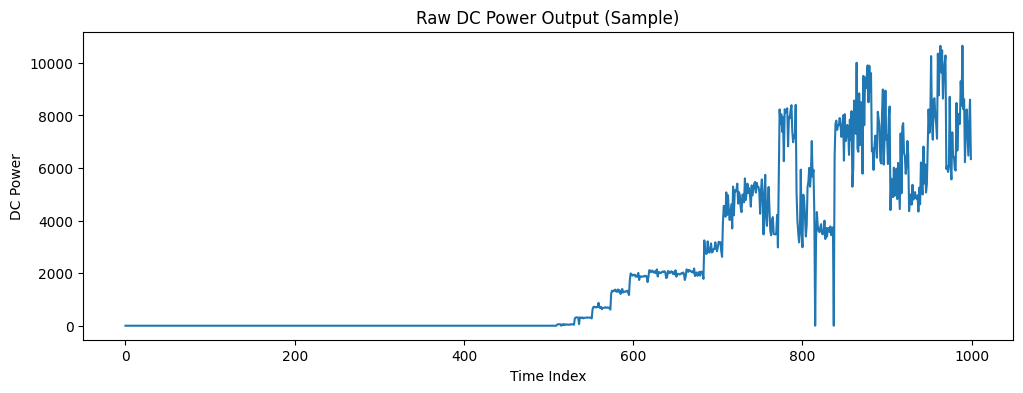

In [13]:
plt.figure(figsize=(12,4))
plt.plot(df["DC_POWER"][:1000])
plt.title("Raw DC Power Output (Sample)")
plt.xlabel("Time Index")
plt.ylabel("DC Power")
plt.show()

<h1> problem 1

In [14]:
df1 = df.copy()

In [15]:
# If there are duplicates in datetime, keep first (or aggregate if needed)
# df = df.drop_duplicates(subset=["DATE_TIME"])

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# rows where ALL three are zero  -> useless for learning generation
mask_all_zero = (
    (df['DC_POWER'] == 0) &
    (df['AC_POWER'] == 0) &
    (df['DAILY_YIELD'] == 0)
)

# drop ONLY those rows
df = df[~mask_all_zero]

In [18]:
anomaly_columns = [
    'DC_POWER',
    'AC_POWER',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION'
]


In [19]:
# Select data for anomaly detection
X_anom = df[anomaly_columns].copy()

# Scale for better detection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anom)

# Isolation Forest
iso = IsolationForest(
    contamination=0.01,
    n_estimators=200,
    random_state=42
)

iso.fit(X_scaled)

df['anomaly'] = iso.predict(X_scaled)
df = df[df['anomaly'] == 1].copy()
df.drop(columns=['anomaly'], inplace=True)

In [20]:
df.describe()

,DATE_TIME,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,Plant
count,105395,1.053950e+05,105395.000000,105395.000000,105395.000000,1.053950e+05,1.053950e+05,105395.000000,105395.000000,105395.000000,105395.000000
mean,2020-06-01 20:57:35.779685888,4.135532e+06,2109.295349,344.783696,4229.887068,3.386690e+08,4.135532e+06,27.649145,34.389309,0.284992,1.531458
min,2020-05-15 00:00:00,4.135001e+06,0.000000,0.000000,0.000000,6.272613e+04,4.135001e+06,20.426455,18.254061,0.000000,1.000000
25%,2020-05-24 09:30:00,4.135001e+06,0.000000,0.000000,1616.483333,6.512002e+06,4.135001e+06,24.461682,23.943915,0.000000,1.000000
50%,2020-06-02 13:15:00,4.136001e+06,367.746667,170.150000,4234.000000,7.292752e+06,4.136001e+06,27.123667,30.992041,0.161657,2.000000
75%,2020-06-10 12:15:00,4.136001e+06,2548.517857,651.263333,6597.000000,2.827135e+08,4.136001e+06,30.161206,43.850724,0.526311,2.000000
max,2020-06-17 23:45:00,4.136001e+06,13806.285710,1385.420000,9873.000000,2.247916e+09,4.136001e+06,39.181638,65.545714,1.098766,2.000000
std,NaN,4.990118e+02,3383.595756,390.119504,2819.310569,6.098338e+08,4.990118e+02,3.799708,11.606280,0.309162,0.499012


Lag features are previous values of the same variable added as new columns to help the model learn patterns over time.

In [21]:
# Lag features (1 hour and 24 hours)
df["DC_lag_1"] = df["DC_POWER"].shift(1)
df["DC_lag_24"] = df["DC_POWER"].shift(24)

In [22]:
# Rolling features (3-hour and 24-hour rolling mean of DC_POWER and IRRADIATION)
df["DC_roll_3"] = df["DC_POWER"].rolling(window=3, min_periods=1).mean().shift(1)
df["IRR_roll_3"] = df["IRRADIATION"].rolling(window=3, min_periods=1).mean().shift(1)
df["IRR_roll_24"] = df["IRRADIATION"].rolling(window=24, min_periods=1).mean().shift(1)

In [23]:
# Percent drop relative to previous hour (useful to detect sudden drops)
df["pct_drop_1h"] = (df["DC_lag_1"] - df["DC_POWER"]) / (df["DC_lag_1"].replace(0, np.nan))
df["pct_drop_1h"] = df["pct_drop_1h"].fillna(0)

In [24]:
# Fill NaNs created by shifting with zeros or sensible values
df.fillna(method="bfill", inplace=True)
df.fillna(0, inplace=True)

In [25]:
# Drop duplicate plant ID columns
df = df.drop(columns=['PLANT_ID_x', 'PLANT_ID_y'], errors='ignore')

# Show remaining columns
df

,DATE_TIME,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,Plant,DC_lag_1,DC_lag_24,DC_roll_3,IRR_roll_3,IRR_roll_24,pct_drop_1h
510,2020-05-15 06:00:00,1BY6WEcLGh8j5v7,37.142857,3.585714,0.0,6259559.0,HmiyD2TTLFNqkNe,24.088446,22.206757,0.005887,1,37.142857,37.142857,37.142857,0.005887,0.005887,0.000000
511,2020-05-15 06:00:00,1IF53ai7Xc0U56Y,53.500000,5.162500,0.0,6183645.0,HmiyD2TTLFNqkNe,24.088446,22.206757,0.005887,1,37.142857,37.142857,37.142857,0.005887,0.005887,-0.440385
512,2020-05-15 06:00:00,3PZuoBAID5Wc2HD,58.000000,5.585714,0.0,6987759.0,HmiyD2TTLFNqkNe,24.088446,22.206757,0.005887,1,53.500000,37.142857,45.321429,0.005887,0.005887,-0.084112
513,2020-05-15 06:00:00,7JYdWkrLSPkdwr4,58.428571,5.628571,0.0,7602960.0,HmiyD2TTLFNqkNe,24.088446,22.206757,0.005887,1,58.000000,37.142857,49.547619,0.005887,0.005887,-0.007389
514,2020-05-15 06:00:00,McdE0feGgRqW7Ca,54.375000,5.250000,0.0,7158964.0,HmiyD2TTLFNqkNe,24.088446,22.206757,0.005887,1,58.428571,37.142857,56.642857,0.005887,0.005887,0.069377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136467,2020-06-17 23:45:00,q49J1IKaHRwDQnt,0.000000,0.000000,4157.0,520758.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.000000,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
136468,2020-06-17 23:45:00,rrq4fwE8jgrTyWY,0.000000,0.000000,3931.0,121131356.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.000000,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
136469,2020-06-17 23:45:00,vOuJvMaM2sgwLmb,0.000000,0.000000,4322.0,2427691.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.000000,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
136470,2020-06-17 23:45:00,xMbIugepa2P7lBB,0.000000,0.000000,4218.0,106896394.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.000000,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [26]:
df.columns

Index(['DATE_TIME', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD',
       'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION', 'Plant', 'DC_lag_1', 'DC_lag_24',
       'DC_roll_3', 'IRR_roll_3', 'IRR_roll_24', 'pct_drop_1h'],
      dtype='object')

In [27]:
df['AC_DC_RATIO'] = df['AC_POWER'] / df['DC_POWER']

In [28]:
features = [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION",
    "DC_roll_3",
    "IRR_roll_3",
    "DC_lag_1",
    "DC_lag_24",
    "IRR_roll_24",
    "pct_drop_1h"
]

target = "DC_POWER"

#(We EXCLUDE IDs, SOURCE_KEY, DATE_TIME, YIELD because they leak info or are not predictive for regression.)

In [29]:
X = df[features].copy()
y = df[target].copy()

In [30]:
# Time-based split (no shuffling)
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

X_test  = X.iloc[split:]
y_test  = y.iloc[split:]

In [31]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

Train shape: (84316, 9) (84316,)
Test shape:  (21079, 9) (21079,)


<h1>FEATURE SELECTION METHOD 1 — CORRELATION ANALYSIS

In [32]:
corr = df[features + [target]].corr()[target].sort_values(ascending=False)
print(corr)

DC_POWER               1.000000
DC_roll_3              0.988934
DC_lag_1               0.985178
DC_lag_24              0.950700
IRRADIATION            0.622894
IRR_roll_3             0.620601
IRR_roll_24            0.610551
MODULE_TEMPERATURE     0.604469
AMBIENT_TEMPERATURE    0.192493
pct_drop_1h           -0.020203
Name: DC_POWER, dtype: float64


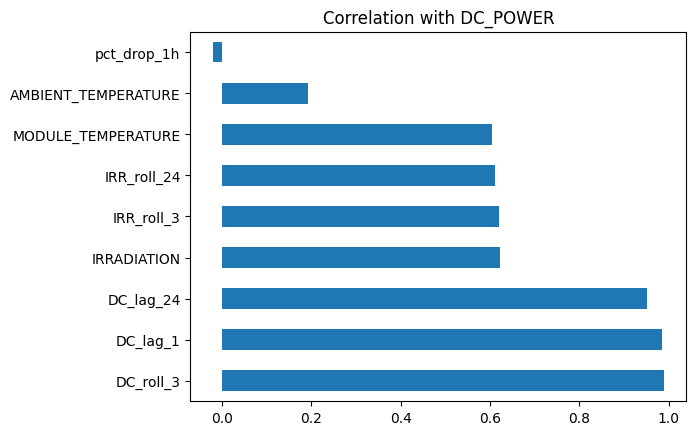

In [33]:
plt.figure()
corr.drop(target).plot(kind="barh", title="Correlation with DC_POWER")
plt.show()


<h1>EATURE SELECTION METHOD 2 — MUTUAL INFORMATION (NON-LINEAR)

In [34]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train)

mi_df = pd.DataFrame({
    "Feature": features,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)

print(mi_df)

               Feature  MI_Score
2          IRRADIATION  2.303108
3            DC_roll_3  2.204222
5             DC_lag_1  2.203491
4           IRR_roll_3  2.068055
1   MODULE_TEMPERATURE  1.889068
0  AMBIENT_TEMPERATURE  1.757475
6            DC_lag_24  1.354431
7          IRR_roll_24  1.338188
8          pct_drop_1h  0.566098


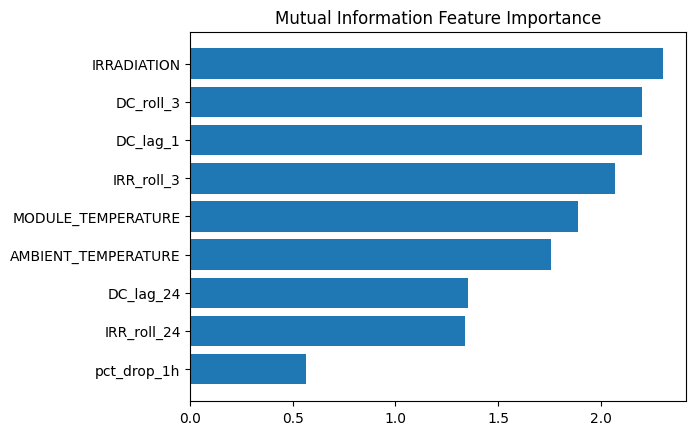

In [35]:
plt.figure()
plt.barh(mi_df["Feature"], mi_df["MI_Score"])
plt.title("Mutual Information Feature Importance")
plt.gca().invert_yaxis()
plt.show()


<h3> FEATURE SELECTION METHOD 3 — RANDOM FOREST IMPORTANCE

In [36]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "Feature": features,
    "RF_Importance": rf.feature_importances_
}).sort_values(by="RF_Importance", ascending=False)

print(rf_importance)

               Feature  RF_Importance
3            DC_roll_3       0.883851
2          IRRADIATION       0.094221
8          pct_drop_1h       0.011531
5             DC_lag_1       0.009279
6            DC_lag_24       0.000413
7          IRR_roll_24       0.000238
1   MODULE_TEMPERATURE       0.000217
4           IRR_roll_3       0.000138
0  AMBIENT_TEMPERATURE       0.000114


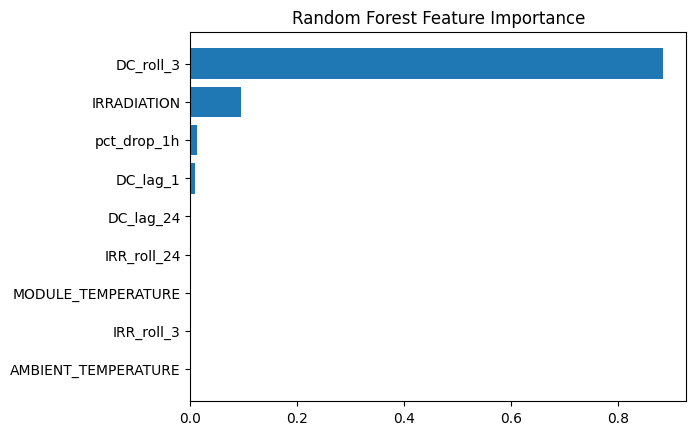

In [37]:
plt.figure()
plt.barh(rf_importance["Feature"], rf_importance["RF_Importance"])
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

<h1> FEATURE SELECTION METHOD 4 — LASSO (AUTOMATIC FEATURE DROPPING)

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

lasso = Lasso(alpha=0.001)
lasso.fit(X_scaled, y_train)

lasso_df = pd.DataFrame({
    "Feature": features,
    "Lasso_Coefficient": lasso.coef_
})

print(lasso_df)

               Feature  Lasso_Coefficient
0  AMBIENT_TEMPERATURE         -26.479089
1   MODULE_TEMPERATURE          55.468024
2          IRRADIATION        2398.401416
3            DC_roll_3        3169.222129
4           IRR_roll_3       -2157.699710
5             DC_lag_1         214.581643
6            DC_lag_24         191.556611
7          IRR_roll_24        -244.377418
8          pct_drop_1h         -87.621319


In [56]:
selected_features = lasso_df[lasso_df["Lasso_Coefficient"] != 0]["Feature"].tolist()
print(" Selected Features:", selected_features)

 Selected Features: ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_roll_3', 'IRR_roll_3', 'DC_lag_1', 'DC_lag_24', 'IRR_roll_24', 'pct_drop_1h']


| Method                             | What it actually measures                           |
| ---------------------------------- | --------------------------------------------------- |
| **Correlation**                    | Linear relationship only                            |
| **Mutual Information**             | Any non-linear dependency                           |
| **Random Forest Importance**       | How often a feature reduces error in decision trees |
| **LASSO**                          | Which features survive regularization               |
| **XGBoost Importance**             | Which features improve boosting splits              |
| **Linear Regression Coefficients** | Linear weight magnitude                             |


***
Different feature selection techniques ranked input variables differently due to the distinct mathematical principles underlying each method. Correlation captured only linear dependency, mutual information captured non-linear relationships, tree-based models measured split-based importance, while LASSO performed embedded regularization-based selection. Therefore, a voting-based consensus approach was adopted. Features that consistently ranked among the top across at least three independent selection methods were chosen for final model training. Additionally, domain knowledge of solar PV systems was incorporated to retain physically significant parameters such as irradiation and module temperature.
***

In [40]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
FEATURES = [
    "IRRADIATION",          # strongest physical driver
    "MODULE_TEMPERATURE",  # panel efficiency effect
    "DC_lag_1",             # short-term memory
    "DC_lag_24",            # daily pattern memory
    "DC_roll_3",            # short-term trend smoothing
    "IRR_roll_24",          # daily solar trend
    "pct_drop_1h"           # cloud/sudden drop indicator
]

TARGET = "DC_POWER"

In [42]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

<h1> METRIC FUNCTION

In [43]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

<h1> RANDOM SPLIT (STANDARD ML)

In [44]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<h1> TIME-BASED SPLIT (REAL FORECASTING)

In [45]:
split = int(len(df) * 0.8)

X_train_t = X.iloc[:split]
y_train_t = y.iloc[:split]

X_test_t  = X.iloc[split:]
y_test_t  = y.iloc[split:]

<h2> DEFINE MODELS

In [46]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=42),
    "ANN (MLP)": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
}

<h1> TRAIN & EVALUATE (RANDOM SPLIT)

In [47]:
results_random = []

for name, model in models.items():
    print("Training (Random):", name)

    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)

    mae  = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2   = r2_score(y_test_r, y_pred)
    mapv = mape(y_test_r, y_pred)

    results_random.append([name, mae, rmse, r2, mapv])

Training (Random): Linear Regression
Training (Random): Random Forest
Training (Random): Gradient Boosting
Training (Random): Extra Trees
Training (Random): ANN (MLP)


In [48]:
results_time = []

for name, model in models.items():
    print("Training (Time):", name)

    model.fit(X_train_t, y_train_t)
    y_pred = model.predict(X_test_t)

    mae  = mean_absolute_error(y_test_t, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_t, y_pred))
    r2   = r2_score(y_test_t, y_pred)
    mapv = mape(y_test_t, y_pred)

    results_time.append([name, mae, rmse, r2, mapv])

Training (Time): Linear Regression
Training (Time): Random Forest
Training (Time): Gradient Boosting
Training (Time): Extra Trees
Training (Time): ANN (MLP)


In [49]:
df_random = pd.DataFrame(
    results_random,
    columns=["Model", "MAE", "RMSE", "R2", "MAPE (%)"]
).sort_values(by="RMSE")

df_time = pd.DataFrame(
    results_time,
    columns=["Model", "MAE", "RMSE", "R2", "MAPE (%)"]
).sort_values(by="RMSE")

print("===== RANDOM SPLIT RESULTS =====")
display(df_random)

print("\n\n")
print("===== TIME SPLIT RESULTS =====")
display(df_time)

===== RANDOM SPLIT RESULTS =====


,Model,MAE,RMSE,R2,MAPE (%)
3,Extra Trees,24.690950,104.833281,0.999043,NaN
1,Random Forest,26.240188,132.466798,0.998472,NaN
2,Gradient Boosting,74.321222,159.770400,0.997777,inf
4,ANN (MLP),67.463428,200.970825,0.996482,inf
0,Linear Regression,188.856307,479.365384,0.979985,inf





===== TIME SPLIT RESULTS =====


,Model,MAE,RMSE,R2,MAPE (%)
1,Random Forest,26.162831,114.695527,0.877384,NaN
3,Extra Trees,28.361762,115.868336,0.874864,NaN
4,ANN (MLP),38.710393,116.083377,0.874399,inf
2,Gradient Boosting,46.487467,119.196142,0.867573,inf
0,Linear Regression,112.467046,257.116024,0.383814,inf


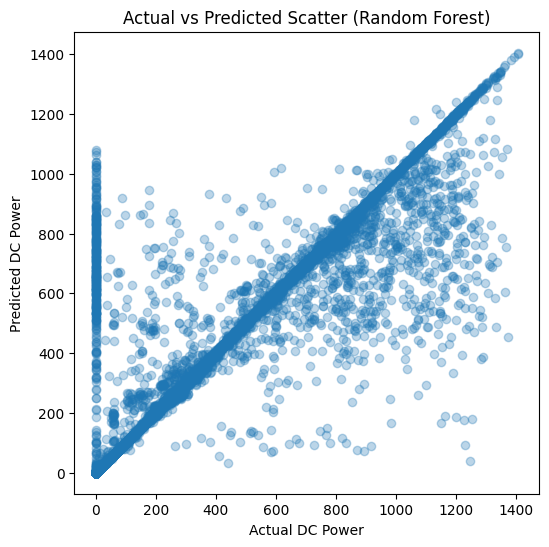

In [50]:
plt.figure(figsize=(6,6))

# Get the Random Forest model and make predictions
rf_model = models["Random Forest"]
rf_model.fit(X_train_t, y_train_t) # Retrain on time-split data
y_pred_rf = rf_model.predict(X_test_t)

plt.scatter(y_test_t, y_pred_rf, alpha=0.3)
plt.xlabel("Actual DC Power")
plt.ylabel("Predicted DC Power")
plt.title("Actual vs Predicted Scatter (Random Forest)")
plt.show()

In [51]:
best_random = df_random.iloc[0]["Model"]
best_time   = df_time.iloc[0]["Model"]

print(" Best Model (Random Split):", best_random)
print(" Best Model (Time Split):", best_time)

 Best Model (Random Split): Extra Trees
 Best Model (Time Split): Random Forest


| Column       | Meaning                                             | What is “Good”?                        |
| ------------ | --------------------------------------------------- | -------------------------------------- |
| **MAE**      | Mean Absolute Error → average absolute mistake      |  Lower is better                      |
| **RMSE**     | Root Mean Squared Error → penalizes big errors more |  Lower is better                      |
| **R²**       | How much variance the model explains                |  Closer to 1 is best                  |
| **MAPE (%)** | Error in percentage                                 |  Lower is better (but see note below) |


<h1> WHY RANDOM SPLIT GIVES HIGHER R² THAN TIME SPLIT

<h3> Random Split:

  * Mixes past + future data randomly

  * The model sees similar patterns in both train and test

  * So accuracy becomes artificially high



<h3> Time Split:

  * Train only on past

  * Test only on future

  * This is realistic solar forecasting

  * Accuracy naturally drops — this is expected and GOOD science

<H1>Interpretation of Results:

  * The random split evaluation shows extremely high R² values (above 0.99) for ensemble models, indicating excellent fitting when data is randomly distributed. Extra Trees achieved the lowest RMSE under random split conditions.

  * However, the time-based split provides a realistic evaluation scenario for solar forecasting. Under time split, Random Forest achieved the lowest RMSE (114.69) and highest R² (0.877), making it the best-performing model for real-world deployment.

  * Linear Regression performed significantly worse in both evaluation strategies, confirming the strong non-linear nature of solar power generation.

  * Artificial Neural Network showed competitive performance but was slightly inferior to tree-based ensemble methods.

  * MAPE values appeared as NaN or infinite due to zero-valued DC power during night-time, which leads to division-by-zero in MAPE calculation.

***
<h1> Conclusion:

This study presented a comprehensive machine learning–based analysis for the prediction of DC power output of a solar photovoltaic (PV) plant using weather, temperature, and engineered time-series features. A carefully selected feature set consisting of irradiation, module temperature, lagged DC power values, rolling averages, and sudden drop indicators was used to capture both the physical and temporal characteristics of solar power generation.

A comparative performance evaluation was carried out using five representative regression models, namely Linear Regression, Random Forest, Gradient Boosting, Extra Trees, and Artificial Neural Network (MLP). The models were evaluated under two different data partitioning strategies: random train–test split and time-based train–test split. While random splitting resulted in very high prediction accuracy due to the mixing of past and future patterns, the time-based split provided a more realistic and practical assessment for real-world solar forecasting applications.

Based on the time-based evaluation results, the Random Forest model emerged as the best-performing predictor, achieving the lowest RMSE and the highest R² score among all models. The Extra Trees model showed comparable performance, confirming the strong capability of ensemble tree-based learning methods in modeling the non-linear behavior of solar power generation. The Artificial Neural Network and Gradient Boosting models delivered reasonable accuracy but remained slightly inferior to ensemble methods. Linear Regression consistently produced the poorest results, highlighting the strongly non-linear nature of the solar PV power output.

It was also observed that the MAPE metric became undefined or infinite due to zero DC power values during night-time, which leads to division-by-zero errors. This limitation reinforced the use of MAE, RMSE, and R² as the primary performance indicators in this study.

In conclusion, this work successfully demonstrates that ensemble learning techniques, particularly Random Forest, are highly effective for short-term solar power prediction under realistic time-series conditions. The presented framework provides a reliable baseline for further improvements such as deep learning–based forecasting, real-time deployment, incorporation of advanced weather features, and intelligent fault detection in solar PV systems.

***

In [52]:
DEPLOY_FEATURES = [
    "IRRADIATION",
    "DC_lag_1",
    "DC_lag_24",
    "DC_roll_3",
    "MODULE_TEMPERATURE"
]

TARGET = "DC_POWER"

X = df[DEPLOY_FEATURES]
y = df[TARGET]

In [53]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,        #  reduced from 200 → 50
    max_depth=15,          #  limits tree size
    min_samples_leaf=5,    #  avoids very deep splits
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [55]:
import joblib

joblib.dump(rf_model, "solar_rf_small.pkl", compress=3)

['solar_rf_small.pkl']